In [1]:

import pandas as pd

In [2]:
  #Reading Dataset
  exercise_data = pd.read_csv( 'exercise.csv' )

In [3]:
exercise_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [4]:
exercise_data.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000


In [5]:
calories_data = pd.read_csv( 'calories.csv' )

In [6]:
calories_data.describe()

,User_ID,Calories
count,1.500000e+04,15000.000000
mean,1.497736e+07,89.539533
std,2.872851e+06,62.456978
min,1.000116e+07,1.000000
25%,1.247419e+07,35.000000
50%,1.499728e+07,79.000000
75%,1.744928e+07,138.000000
max,1.999965e+07,314.000000


In [7]:
# joining both CSV files using User_ID as key and left outer join
joined_data = exercise_data.join( calories_data.set_index( 'User_ID' ), on='User_ID', how='left')
joined_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [8]:
# Check for null values
print(joined_data.isnull().sum())


User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64


In [9]:
# Check for missing values
print(joined_data.isna().sum())

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64


/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


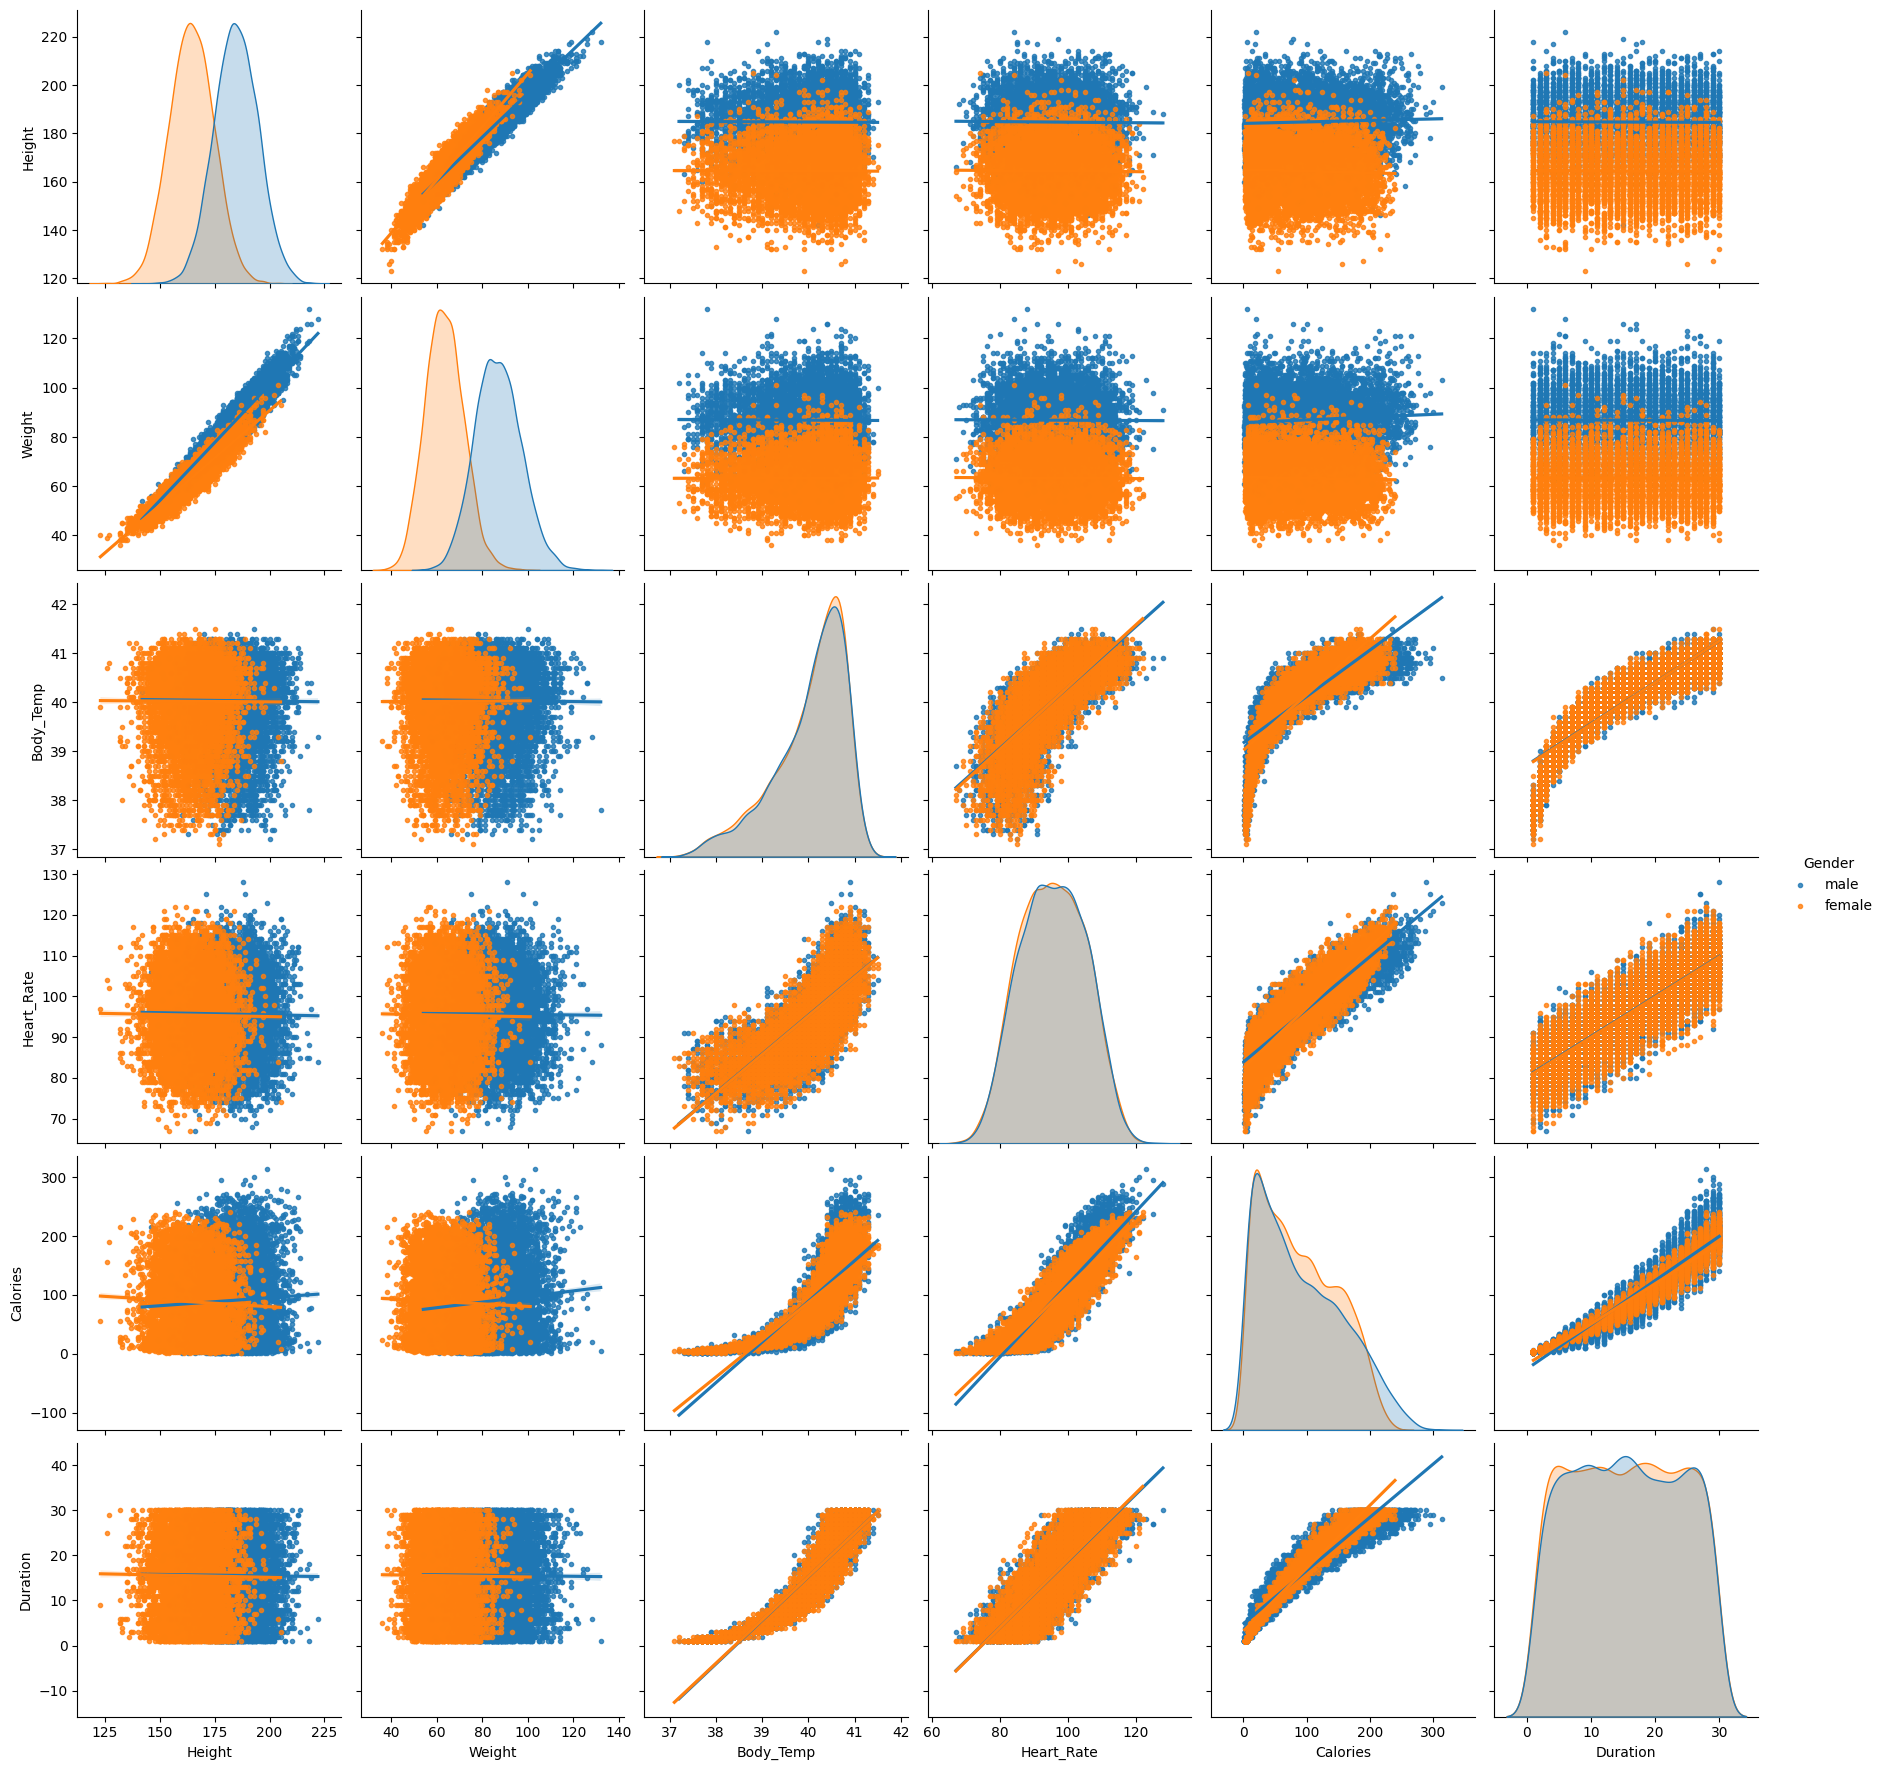

In [10]:
# matrix of scatter plot graphs
%matplotlib inline

import seaborn as sns

cols = [ "Height", "Weight", "Body_Temp", "Heart_Rate", "Calories", "Duration", "Gender" ]

# shows gender in different colors and a linear regression model for each
plot = sns.pairplot( joined_data[ cols ], size=3, markers=".", hue="Gender", kind="reg" )

# get x labels from the last row and save them into an array
xlabels = []
for ax in plot.axes[ -1, : ]:
    xlabel = ax.xaxis.get_label_text()
    xlabels.append( xlabel )

# apply x labels from the array to the rest of the graphs
y_ax_len = len( plot.axes[ :, 0 ] )
for i in range( len( xlabels ) ):
    for j in range( y_ax_len ):
        if j != i :
            plot.axes[ j, i ].xaxis.set_label_text( xlabels[ i ] )

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns

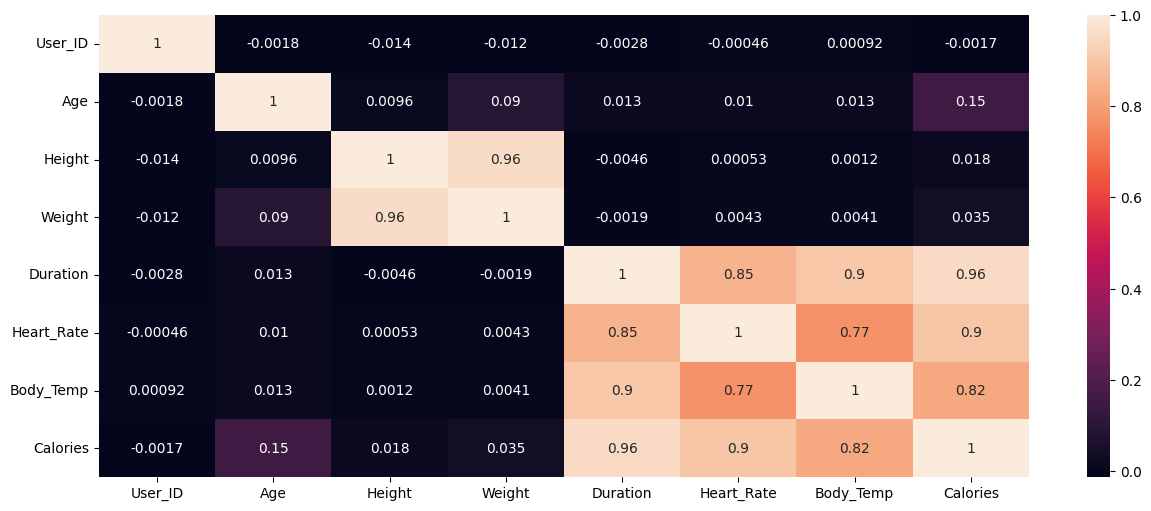

In [12]:
#Visualization of the correlation between the different columns in the dataset.
plt.figure(figsize=(15,6))

# Select only numerical features for correlation calculation
numerical_features = joined_data.select_dtypes(include=np.number)

sns.heatmap(numerical_features.corr(),annot=True)
plt.show()

In [13]:
#Feature Engineering

In [14]:
joined_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [15]:
# Create a new feature for body mass index (BMI)
joined_data["BMI"] = joined_data["Weight"] / (joined_data["Height"] / 100) ** 2

# Create a new feature for heart rate percentage of maximum heart rate
joined_data["Heart_Rate_Percentage"] = joined_data["Heart_Rate"] / (220 - joined_data["Age"])

# Create a new feature for duration in minutes
joined_data["Duration_Minutes"] = joined_data["Duration"] / 60

# Create a new feature for total energy expenditure (TEE)
joined_data["TEE"] = joined_data["Calories"] + (joined_data["Duration_Minutes"] * 5.0) + (joined_data["BMI"] * 10.0)

# Create a new feature for age groups
bins = [0, 18, 30, 45, 60, 120]
labels = ["<18", "18-30", "30-45", "45-60", ">60"]
joined_data["Age_Group"] = pd.cut(joined_data["Age"], bins=bins, labels=labels)

# Create a new feature for BMI groups
bins = [0, 18.5, 25, 30, 100]
labels = ["Underweight", "Normal", "Overweight", "Obese"]
joined_data["BMI_Group"] = pd.cut(joined_data["BMI"], bins=bins, labels=labels)


In [16]:
joined_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,BMI,Heart_Rate_Percentage,Duration_Minutes,TEE,Age_Group,BMI_Group
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0,26.038781,0.690789,0.483333,493.804478,>60,Overweight
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0,21.773842,0.470000,0.233333,284.905090,18-30,Normal
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0,24.655910,0.582781,0.083333,272.975763,>60,Normal
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0,22.159109,0.537634,0.216667,293.674420,30-45,Normal
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0,24.456063,0.419689,0.166667,280.393968,18-30,Normal


In [17]:
# Drop the User_ID column
joined_data.drop(columns=["User_ID"], inplace=True)

In [18]:
#Data Preprocessing

In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
# Convert Gender column to binary
joined_data["Gender"] = pd.get_dummies(joined_data["Gender"], drop_first=True)

# Select numerical columns for filling missing values
numerical_cols = joined_data.select_dtypes(include=np.number).columns

# Fill missing values in numerical columns with their mean
joined_data[numerical_cols] = joined_data[numerical_cols].fillna(joined_data[numerical_cols].mean())

# Standardize the data
scaler = StandardScaler()
joined_data[["Age","Height", "Weight","Duration", "Heart_Rate", "Body_Temp", "Calories"]] = scaler.fit_transform(joined_data[["Age","Height", "Weight","Duration", "Heart_Rate", "Body_Temp", "Calories"]])

In [21]:
# Log square root transformation
# Create the log square root transformations for the columns
joined_data['log_age'] = np.log(joined_data['Age'])
joined_data['sqrt_Height'] = np.sqrt(joined_data['Height'])
joined_data['log_weight'] = np.log(joined_data['Weight'])
joined_data['log_Duration'] = np.log(joined_data['Duration'])
joined_data['sqrt_Heart_Rate'] = np.sqrt(joined_data['Heart_Rate'])
joined_data['sqrt_Body_Temp'] = np.sqrt(joined_data['Body_Temp'])
joined_data['log_BMI'] = np.log(joined_data['BMI'])


/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr

In [22]:
# Save the preprocessed data to a new CSV file
joined_data.to_csv("preprocessed_data.csv", index=False)

In [23]:
#Model Selection


In [24]:
# Split the dataset into input features and target variables
X = joined_data.drop(['Calories', 'Gender', 'Age_Group','BMI_Group'], axis=1)
y = joined_data['Calories']




In [25]:
#Scaling the data
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 1.48472604,  1.08958204,  1.26590864, ...,  0.4406983 ,
         0.87126956,  1.0754102 ],
       [-1.34217934, -0.59372619, -0.99545805, ...,         nan,
        -0.79448192, -1.69915127],
       [ 1.5436199 ,  0.31806577,  0.26824686, ...,         nan,
                nan,  0.22897176],
       ...,
       [ 0.01237949, -1.08469109, -1.12847962, ...,         nan,
        -1.9682809 , -0.88846209],
       [ 2.07366466,  1.29999557,  1.465441  , ...,         nan,
                nan,  1.07671254],
       [ 1.19025673, -0.10276129,  0.26824686, ...,         nan,
        -0.02313643,  1.28663865]])

In [26]:
# Drop any rows with missing values in y
y.dropna(inplace=True)

In [27]:
# Drop any rows with missing values in X
X.dropna(inplace=True)

In [28]:

# Scale the input features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [29]:
# assuming X and y are numpy arrays
X = X[:617]
y = y[:617]

# split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [30]:
#Remove customer IDs from the data set
joined_data = joined_data.iloc[:,1:]

#Convertin the predictor variable in a binary numeric variable
joined_data ['Calories'].replace(to_replace='Yes', value=1, inplace=True)
joined_data ['Calories'].replace(to_replace='No',  value=0, inplace=True)

#Let's convert all the categorical variables into dummy variables
joined_data_dummies = pd.get_dummies(joined_data )
joined_data_dummies.head()

<ipython-input-30-85de12c91e49>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  joined_data ['Calories'].replace(to_replace='Yes', value=1, inplace=True)
<ipython-input-30-85de12c91e49>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,BMI,Heart_Rate_Percentage,Duration_Minutes,...,log_BMI,Age_Group_<18,Age_Group_18-30,Age_Group_30-45,Age_Group_45-60,Age_Group_>60,BMI_Group_Underweight,BMI_Group_Normal,BMI_Group_Overweight,BMI_Group_Obese
0,1.484726,1.089582,1.265909,1.619127,0.989404,0.994023,2.265002,26.038781,0.690789,0.483333,...,3.259587,False,False,False,False,True,False,False,True,False
1,-1.342179,-0.593726,-0.995458,-0.183990,-0.158461,0.352342,-0.376905,21.773842,0.470000,0.233333,...,3.080709,False,True,False,False,False,False,True,False,False
2,1.543620,0.318066,0.268247,-1.265861,-0.784569,-1.701035,-1.017367,24.655910,0.582781,0.083333,...,3.205017,False,False,False,False,True,False,True,False,False
3,-0.517665,0.318066,-0.263839,-0.304198,0.467647,0.609015,-0.296847,22.159109,0.537634,0.216667,...,3.098249,False,False,True,False,False,False,True,False,False
4,-0.929922,-1.435380,-1.128480,-0.664821,-1.515029,-0.289338,-0.873263,24.456063,0.419689,0.166667,...,3.196878,False,True,False,False,False,False,True,False,False


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.85338375,  0.38405153,  0.49163881, ...,  0.28931847,
         0.63818005,  0.42413794],
       [ 0.09849088, -0.11402476,  0.49163881, ..., -1.7118789 ,
        -0.84728467,  1.35726267],
       [-1.41129485, -0.3630629 , -0.38602092, ...,  1.60028531,
         0.63818005, -0.1190276 ],
       ...,
       [-0.8451252 , -1.23469639, -1.59280306, ..., -2.27426139,
        -0.84728467, -1.41905236],
       [-1.22257163,  0.25953246, -0.27631346, ...,  0.62166016,
         0.94343193, -1.04133973],
       [ 0.00412928, -0.48758197, -0.27631346, ...,  1.06984572,
        -0.03835936,  0.37346708]])

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=30)

In [33]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [34]:
model.fit(X_train, y_train)

LinearRegression()

In [35]:
model.score(X_test, y_test)

-0.08827535927533203

In [36]:
from sklearn.decomposition import PCA

pca = PCA(0.95)
X_pca = pca.fit_transform(X)
X_pca.shape

(617, 1)

In [37]:
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X)
X_pca.shape

(617, 10)

In [38]:
pca.explained_variance_ratio_

array([9.97494319e-01, 9.95663724e-04, 7.54967236e-04, 3.89857107e-04,
       1.47437710e-04, 9.03951981e-05, 4.89824249e-05, 4.06694304e-05,
       3.03274499e-05, 3.88836441e-06])

In [39]:
X_pca

array([[ 6.55838410e+01, -2.08206207e-01, -5.39191944e-01, ...,
         3.16196843e-02, -2.51233058e-01,  5.03299063e-02],
       [-2.07659339e+01, -1.78610515e+00, -5.46604200e-01, ...,
         2.59961646e-01, -1.38412082e-01, -6.63985415e-02],
       [ 2.78551806e+01,  8.55505764e-01,  2.48965903e+00, ...,
        -3.78192881e-02,  2.80995502e-01, -7.14155386e-02],
       ...,
       [-1.03595765e+02,  3.72790637e+00, -9.31988615e-01, ...,
        -5.17895814e-01, -7.26235779e-01, -9.97576287e-02],
       [ 1.47645463e+00,  9.58661405e-01,  1.51439245e+00, ...,
        -2.17774245e-01, -1.37788232e-02, -4.27270910e-03],
       [ 4.57247978e+01,  3.05645307e-01, -1.43693155e-01, ...,
         1.26225547e-01, -1.54576226e-01, -2.66754130e-02]])

In [40]:
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=30)

In [41]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [42]:
model.fit(X_train_pca, y_train)

LinearRegression()

In [43]:
Lin_Reg_MS = model.score(X_test_pca, y_test)
Lin_Reg_MS

-0.06732604671948828

In [44]:
Y_pred = model.predict(X_test_pca)

In [45]:
y_test

,Calories
236,-0.729159
481,0.519743
239,0.279569
24,-1.385632
47,0.823962
...,...
31,0.743904
295,1.432401
413,-1.257540
108,0.823962


In [46]:
def adj_r_squared(y_true, y_pred, n_features):
    n = len(y_true)
    residuals = y_true - y_pred
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - ss_res / ss_tot
    adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - n_features - 1))
    return adj_r2

In [47]:
Lin_Reg_AR2 = adj_r_squared(y_test, Y_pred, 2)
Lin_Reg_AR2

-0.08496779955782685

In [48]:
from sklearn.metrics import mean_squared_error

In [49]:
Lin_Reg_Mse = mean_squared_error(y_test,Y_pred)
Lin_Reg_Mse

1.173687756066081

In [50]:
#Ridge Regression
from sklearn.linear_model import Ridge

In [51]:
ridge_model = Ridge(alpha=1)

In [52]:
ridge_model.fit(X_train_pca, y_train)

Ridge(alpha=1)

In [53]:
y_pred_ridge = ridge_model.predict(X_test_pca)

In [54]:
Ridge_Mse = mean_squared_error(y_test,y_pred_ridge)
Ridge_Mse


1.1714478959341745

In [55]:
Ridge_MS = ridge_model.score(X_test_pca, y_test)
Ridge_MS

-0.06528916676786878

In [56]:
Ridge_AR2 = adj_r_squared(y_test, y_pred_ridge, 2)
Ridge_AR2

-0.0828972521689908

In [57]:
#Lasso Regression
from sklearn.linear_model import Lasso

In [58]:
lasso_model = Lasso(alpha=1.0)


In [59]:
lasso_model.fit(X_train_pca, y_train)

Lasso()

In [60]:
y_pred_lasso = lasso_model.predict(X_test_pca)

In [61]:
Lasso_Mse = mean_squared_error(y_test,y_pred_lasso)
Lasso_Mse

1.1239976261453863

In [62]:
Lasso_MS = lasso_model.score(X_test_pca, y_test)
Lasso_MS

-0.02213892633323189

In [63]:
Lasso_AR2 = adj_r_squared(y_test, y_pred_lasso, 2)
Lasso_AR2

-0.039033784619731504

In [64]:
#Support Vector Regression
from sklearn.svm import SVR

In [65]:
svr_model = SVR(kernel='linear', C=1.0, epsilon=0.1)

In [66]:
svr_model.fit(X_train_pca, y_train)

SVR(kernel='linear')

In [67]:
y_pred_SVR = svr_model.predict(X_test_pca)

In [68]:
SVR_Mse = mean_squared_error(y_test,y_pred_SVR)
SVR_Mse

1.2213656895402998

In [69]:
SVR_MS = svr_model.score(X_test_pca, y_test)
SVR_MS

-0.11068331954421007

In [70]:
SVR_AR2 = adj_r_squared(y_test, y_pred_SVR, 2)
SVR_AR2

-0.12904172152014737

In [71]:
pip install xgboost

In [72]:
#XG Boost Regression

!pip install scikit-learn==1.2.0
import sklearn
print(sklearn.__version__)
from xgboost import XGBRegressor



1.2.0


In [73]:
xgb_model = XGBRegressor(learning_rate=0.1, max_depth=3, n_estimators=100)

In [74]:
xgb_model.fit(X_train_pca, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [75]:
y_pred_XGB = xgb_model.predict(X_test_pca)

In [76]:
XGB_Mse = mean_squared_error(y_test,y_pred_XGB)
XGB_Mse

1.2724067264224106

In [77]:
XGB_MS = xgb_model.score(X_test_pca, y_test)
XGB_MS

-0.15709892525730207

In [78]:
XGB_AR2 = adj_r_squared(y_test, y_pred_XGB, 2)
XGB_AR2

-0.17622452732767058

In [79]:
#Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

In [80]:
dt_model = DecisionTreeRegressor(max_depth=3)

In [81]:
dt_model.fit(X_train_pca, y_train)

DecisionTreeRegressor(max_depth=3)

In [82]:
y_pred_dt = dt_model.predict(X_test_pca)

In [83]:
DT_Mse = mean_squared_error(y_test,y_pred_dt)
DT_Mse

1.179678740136945

In [84]:
DT_MS = dt_model.score(X_test_pca, y_test)
DT_MS

-0.07277411696753022

In [85]:
DT_AR2 = adj_r_squared(y_test, y_pred_dt, 2)
DT_AR2

-0.09050592055377038

In [86]:
#Model Scores
print("Linear regression Model Score ", Lin_Reg_MS)
print("Ridge regression Model Score ", Ridge_MS)
print("Lasso regression Model Score ", Lasso_MS)
print("SVR regression Model Score ", SVR_MS)
print("XGB regression Model Score ", XGB_MS)
print("Decision Tree regression Model Score ", DT_MS)

Linear regression Model Score  -0.06732604671948828
Ridge regression Model Score  -0.06528916676786878
Lasso regression Model Score  -0.02213892633323189
SVR regression Model Score  -0.11068331954421007
XGB regression Model Score  -0.15709892525730207
Decision Tree regression Model Score  -0.07277411696753022


In [87]:
#MSE Values
print("Linear regression Model Score ", Lin_Reg_Mse)
print("Ridge regression Model Score ", Ridge_Mse)
print("Lasso regression Model Score ", Lasso_Mse)
print("SVR regression Model Score ", SVR_Mse)
print("XGB regression Model Score ", XGB_Mse)
print("Decision Tree regression Model Score ", DT_Mse)

Linear regression Model Score  1.173687756066081
Ridge regression Model Score  1.1714478959341745
Lasso regression Model Score  1.1239976261453863
SVR regression Model Score  1.2213656895402998
XGB regression Model Score  1.2724067264224106
Decision Tree regression Model Score  1.179678740136945


In [88]:
#Adjusted R2 Values
print("Linear regression Model Score ", Lin_Reg_AR2)
print("Ridge regression Model Score ", Ridge_AR2)
print("Lasso regression Model Score ", Lasso_AR2)
print("SVR regression Model Score ", SVR_AR2)
print("XGB regression Model Score ", XGB_AR2)
print("Decision Tree regression Model Score ", DT_AR2)

Linear regression Model Score  -0.08496779955782685
Ridge regression Model Score  -0.0828972521689908
Lasso regression Model Score  -0.039033784619731504
SVR regression Model Score  -0.12904172152014737
XGB regression Model Score  -0.17622452732767058
Decision Tree regression Model Score  -0.09050592055377038
